# 🎓 Student Placement Prediction

## 📌 Project Overview
In this notebook, we aim to predict whether a student will get placed based on various academic and skill-based features. We will explore the dataset, perform EDA, and train multiple machine learning models to find the best predictor.

In [11]:
pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.4
packaging               26.0
pandas                  3.0.2
parso                   0.8.6
pillow                  12.2.0
pip                     26.0.1
platformdirs            4.9.4
prompt_toolkit          3.0.52
psutil                  7.2.2
pure_eval               0.2.3
Pygments                

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [13]:
# import pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## 1️⃣ Loading Data & Initial Checks
Loading the training and testing datasets and merging them for preprocessing.

In [14]:
df1 = pd.read_csv('test.csv')
df2 = pd.read_csv('train.csv')
df1.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,38881,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,30191,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


In [15]:
df2.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [16]:
# merge both csv file
df = pd.concat([df1,df2])
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,38881,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,30191,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


In [17]:
# df info
df.info()

<class 'pandas.DataFrame'>
Index: 50000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            50000 non-null  int64  
 1   Age                   50000 non-null  int64  
 2   Gender                50000 non-null  str    
 3   Degree                50000 non-null  str    
 4   Branch                50000 non-null  str    
 5   CGPA                  50000 non-null  float64
 6   Internships           50000 non-null  int64  
 7   Projects              50000 non-null  int64  
 8   Coding_Skills         50000 non-null  int64  
 9   Communication_Skills  50000 non-null  int64  
 10  Aptitude_Test_Score   50000 non-null  int64  
 11  Soft_Skills_Rating    50000 non-null  int64  
 12  Certifications        50000 non-null  int64  
 13  Backlogs              50000 non-null  int64  
 14  Placement_Status      50000 non-null  str    
dtypes: float64(1), int64(10), str(4)
me

In [18]:
df.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,21.000000,7.002602,0.773740,3.735680,5.694700,5.499860,69.399120,5.502460,1.801580,0.886300
std,14433.901067,1.995034,0.994511,0.845506,0.923359,1.993944,1.516313,13.906613,1.239171,0.649906,0.969841
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12500.750000,19.000000,6.327500,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,25000.500000,21.000000,7.000000,1.000000,4.000000,6.000000,5.000000,69.000000,6.000000,2.000000,1.000000
75%,37500.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


## 2️⃣ Data Cleaning
* Checking for null values and duplicates.
* Dropping unnecessary ID columns.

In [19]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
# drop unusefull columns
df.drop(['Student_ID'],axis=1,inplace=True)

In [22]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


## 3️⃣ Exploratory Data Analysis (EDA)
Analyzing correlations and feature distributions to understand the data patterns.

In [23]:
df['Gender'].value_counts()

Gender
Female    25065
Male      24935
Name: count, dtype: int64

In [24]:
df['Degree'].value_counts()

Degree
B.Sc      12613
MCA       12575
B.Tech    12543
BCA       12269
Name: count, dtype: int64

In [25]:
# ME - mechanical engineering
# ECE - electronics and communications engineering
# cse - Computer science engineering

In [26]:
df['Branch'].value_counts()

Branch
ME       10038
ECE      10030
CSE       9993
IT        9983
Civil     9956
Name: count, dtype: int64

In [27]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Gender', 'Degree', 'Branch', 'Placement_Status'], dtype='str')

In [28]:
def encode_df(df,cat_cols):
  for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
  return df

In [29]:
copy_df = df.copy()

In [30]:
encoded_df = encode_df(copy_df,cat_cols)

encoded_df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,23,1,1,1,7.32,2,4,5,6,56,6,1,0,1
1,24,0,3,4,4.76,0,1,1,4,37,4,0,3,0
2,20,1,2,4,6.16,0,3,3,8,68,6,1,3,0
3,19,1,0,3,8.77,2,5,8,5,83,6,3,0,1
4,23,1,1,4,7.63,0,3,4,6,66,7,1,0,0


<Axes: >

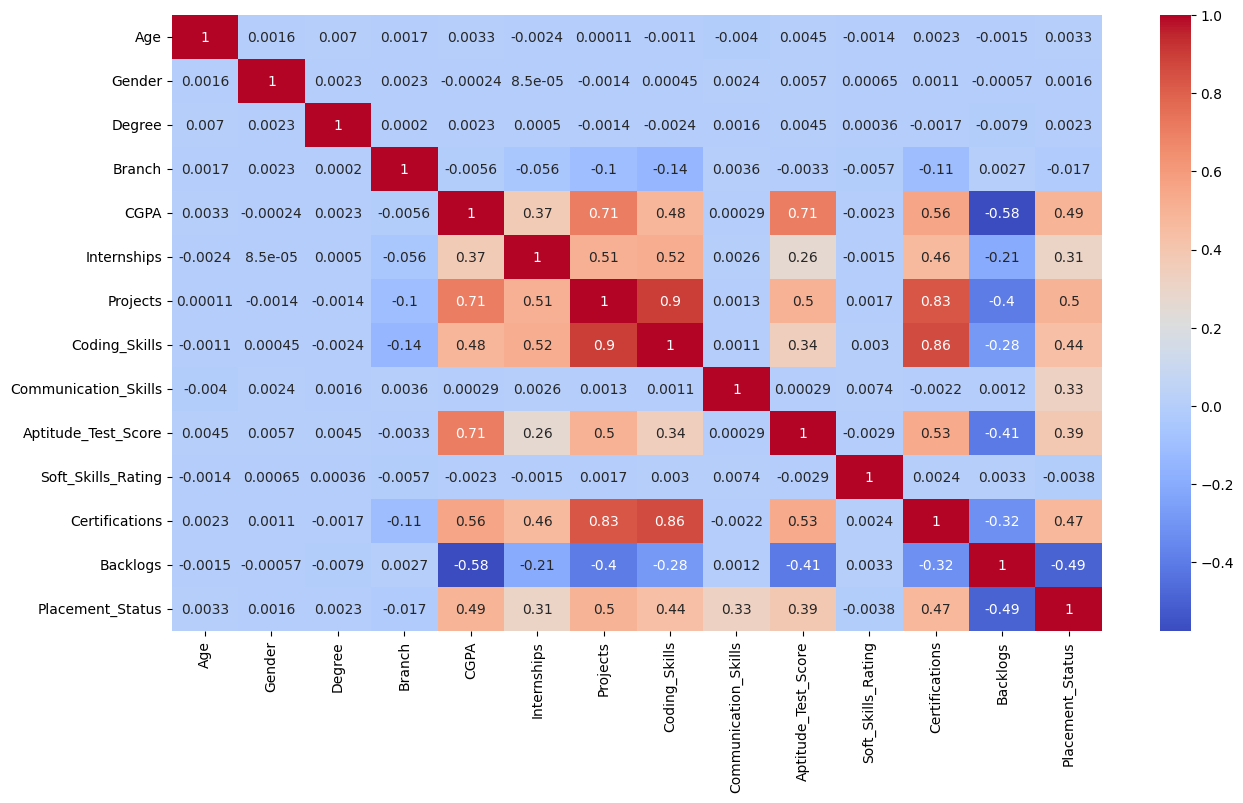

In [31]:
plt.figure(figsize=(15,8))
sns.heatmap(encoded_df.corr(),annot=True,cmap='coolwarm')

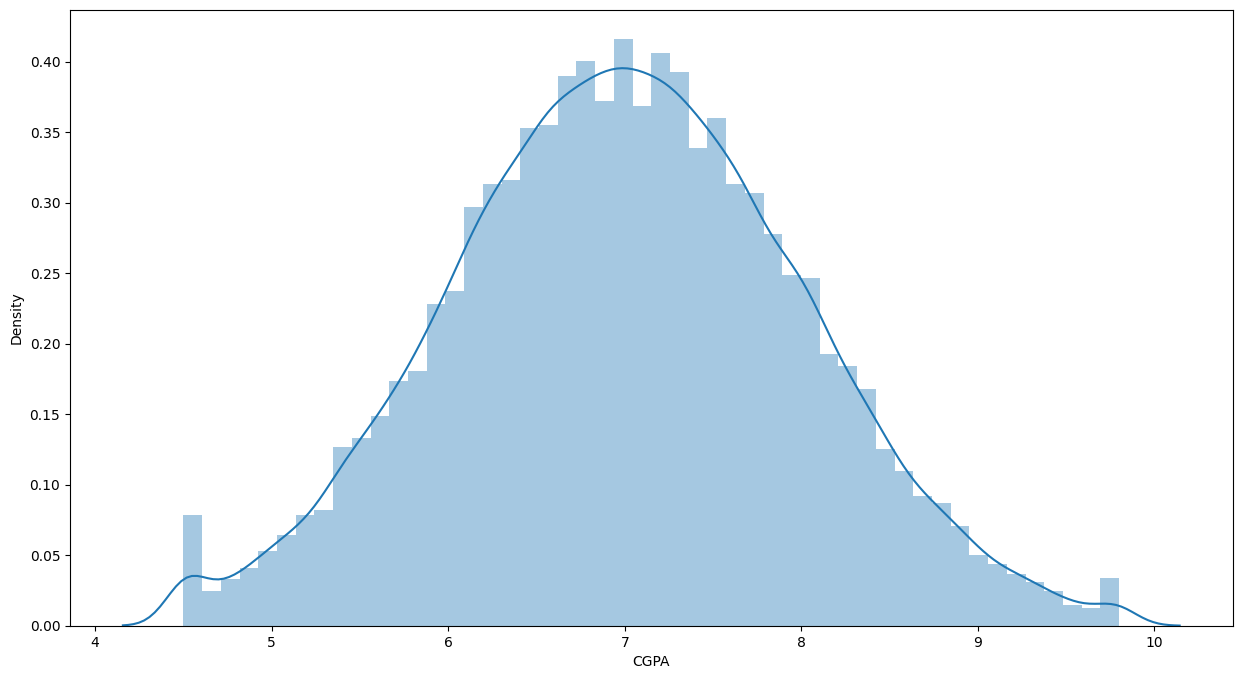

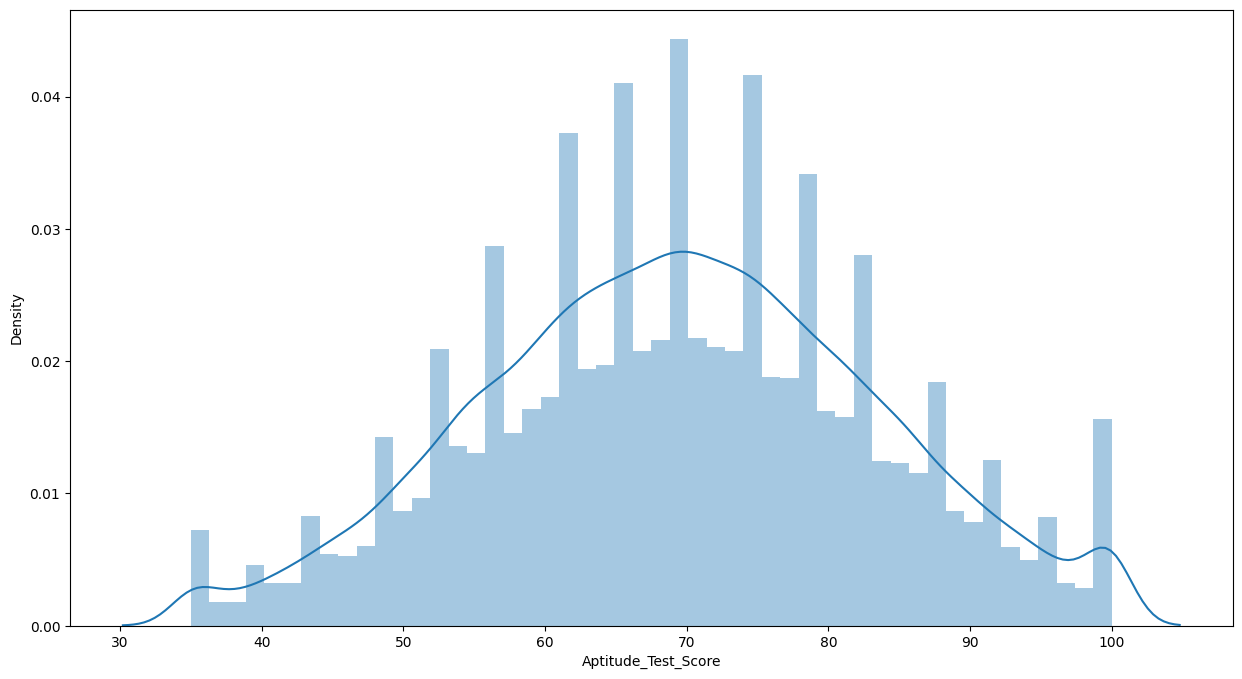

In [32]:
# make distrubtion plot
df_dist = encoded_df[['CGPA','Aptitude_Test_Score']]

for col in df_dist.columns:
  plt.figure(figsize=(15,8))
  sns.distplot(df_dist[col])

In [33]:
df_dist.skew()

CGPA                   0.032199
Aptitude_Test_Score   -0.034235
dtype: float64

## 4️⃣ Model Configuration
We define a dictionary of models and their hyperparameters for `GridSearchCV`.

In [34]:
models = {
    'Logistic Regression':{
        'model': LogisticRegression(),
        'params': {
            'C':[0.1,1,10],
            'max_iter': [1000, 2000]
        }
    },
    'Decision Tree':{
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'criterion':['gini','entropy'],
            'max_depth':[5,10]
        }
    },
    'Random Forest':{
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators':[100,200],
            'max_depth':[5,10]
        }
    },
    'XGBoost':{
        'model': XGBClassifier(),
        'params': {
            'n_estimators':[100,200],
            'learning_rate':[0.1,0.01]
        }
    },
    'KNN':{
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors':[5,10],
            'weights':['uniform','distance']
        }
    }
}

In [35]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


## 5️⃣ Data Splitting & Preprocessing Pipeline
* Target Mapping: `Placed` -> 1, `Not Placed` -> 0.
* **ColumnTransformer**: OneHotEncoding for categorical features, Scaling for numerical features.

In [36]:
x = df.drop('Placement_Status',axis=1)
y = df['Placement_Status']
y = y.map({'Placed':1,'Not Placed':0})

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(exclude='object').columns

print(cat_cols)
print(num_cols)

Index(['Gender', 'Degree', 'Branch'], dtype='str')
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='str')


## 6️⃣ Model Training (GridSearch)
Iterating through each model to find the best hyperparameters and accuracy.

In [38]:
%%time

model_scores = []

best_accuracy_score = float('-inf')
best_model = None

cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('num',StandardScaler(),num_cols)
])

for name , model in models.items():
  print(f'Training {name} model')

  pipe = Pipeline([
      ('preprocess',preprocess),
      ('model',model['model'])
  ])

  grid_params = {f'model__{k}': v for k, v in model['params'].items()}

  grid = GridSearchCV(
      pipe,
      param_grid=grid_params,
      cv=5,
      n_jobs=-1,
      verbose=0
  )

  grid.fit(x_train,y_train)

  y_pred = grid.predict(x_test)

  accuracy = accuracy_score(y_test,y_pred)
  class_report = classification_report(y_test,y_pred)
  conf_matrix = confusion_matrix(y_test,y_pred)

  model_scores.append({
      'model':name,
      'accuracy':accuracy,
      'best_params':grid.best_params_,
      'best_score':grid.best_score_,
      'class_report':class_report,
      'confusion_matrix':conf_matrix,
      'best_estimator': grid.best_estimator_
  })

  if accuracy > best_accuracy_score:
    best_accuracy_score = accuracy
    best_model = name

model_sorted = sorted(model_scores,key=lambda x:x['accuracy'],reverse=True)
best_accuracy_model = max(model_scores,key=lambda x:x['accuracy'])

Training Logistic Regression model
Training Decision Tree model
Training Random Forest model
Training XGBoost model
Training KNN model
CPU times: total: 11.9 s
Wall time: 29 s


In [39]:
best_accuracy_model

{'model': 'Decision Tree',
 'accuracy': 1.0,
 'best_params': {'model__criterion': 'gini', 'model__max_depth': 10},
 'best_score': np.float64(1.0),
 'class_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      6382\n           1       1.00      1.00      1.00      3618\n\n    accuracy                           1.00     10000\n   macro avg       1.00      1.00      1.00     10000\nweighted avg       1.00      1.00      1.00     10000\n',
 'confusion_matrix': array([[6382,    0],
        [   0, 3618]]),
 'best_estimator': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   Index(['Gender', 'Degree', 'Branch'], dtype='str')),
                                                  ('num', StandardScaler(),
                                                   In

## 7️⃣ Results & Analysis
Comparing the accuracy of all trained models.

In [40]:
model_df = pd.DataFrame(model_sorted)
model_df

,model,accuracy,best_params,best_score,class_report,confusion_matrix,best_estimator
0,Decision Tree,1.0000,"{'model__criterion': 'gini', 'model__max_depth...",1.00000,precision recall f1-score ...,"[[6382, 0], [0, 3618]]","(ColumnTransformer(transformers=[('cat', OneHo..."
1,Random Forest,1.0000,"{'model__max_depth': 10, 'model__n_estimators'...",0.99995,precision recall f1-score ...,"[[6382, 0], [0, 3618]]","(ColumnTransformer(transformers=[('cat', OneHo..."
2,XGBoost,1.0000,"{'model__learning_rate': 0.1, 'model__n_estima...",1.00000,precision recall f1-score ...,"[[6382, 0], [0, 3618]]","(ColumnTransformer(transformers=[('cat', OneHo..."
3,KNN,0.9442,"{'model__n_neighbors': 10, 'model__weights': '...",0.94505,precision recall f1-score ...,"[[5995, 387], [171, 3447]]","(ColumnTransformer(transformers=[('cat', OneHo..."
4,Logistic Regression,0.8670,"{'model__C': 1, 'model__max_iter': 1000}",0.86785,precision recall f1-score ...,"[[5721, 661], [669, 2949]]","(ColumnTransformer(transformers=[('cat', OneHo..."


## 8️⃣ Why 100% Accuracy? (Feature Importance)
Since tree-based models achieved 100% accuracy, we analyze the **Feature Importance** to see which features are driving this perfect prediction. This helps identify if the data is synthetic or has a specific rule.

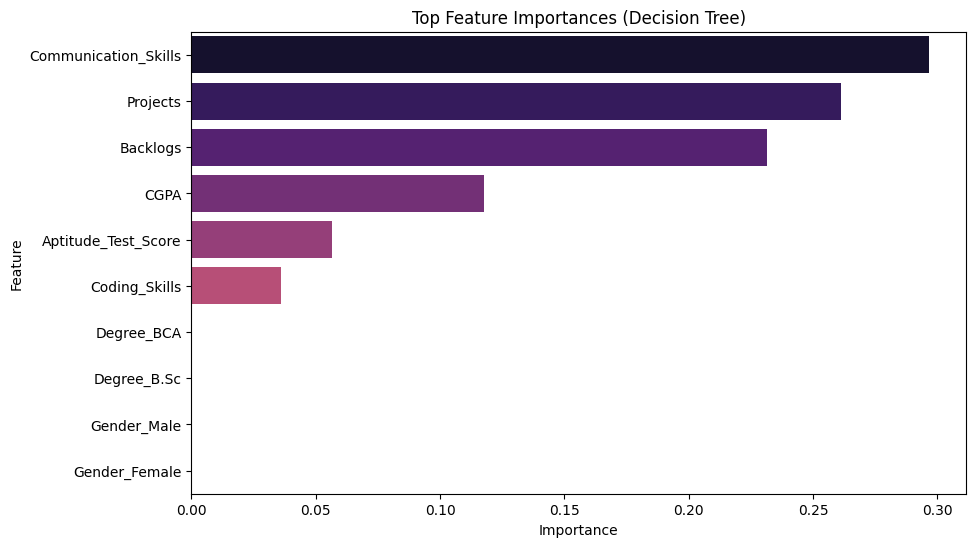

In [41]:
# Get the best model (Likely Random Forest or XGBoost)
best_pipeline = model_df.iloc[0]['best_estimator']
best_model_step = best_pipeline.named_steps['model']

# Check if model has feature_importances_
if hasattr(best_model_step, 'feature_importances_'):

    # Get feature names from preprocessor
    # Note: OneHotEncoder adds extra columns, so we need to retrieve them
    ohe_cols = best_pipeline.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(cat_cols)
    all_feats = list(ohe_cols) + list(num_cols)

    # Get importances
    importances = best_model_step.feature_importances_

    feat_df = pd.DataFrame({'Feature': all_feats, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
    plt.title(f'Top Feature Importances ({model_df.iloc[0]["model"]})')
    plt.show()
else:
    print("The best model does not support feature importance (e.g., KNN).")

In [42]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('num',StandardScaler(),num_cols)
])

In [43]:
new_model = Pipeline(steps=[
    ('preprocessor', preprocess),
    ('model', DecisionTreeClassifier(criterion='gini', max_depth=10))
])

new_model.fit(x_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [44]:
import joblib

In [46]:
joblib.dump(new_model, "placement_prediction_model.pkl")

['placement_prediction_model.pkl']